In [ ]:
import re
from difflib import SequenceMatcher
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Known placeholders (adjust if needed)
PLACEHOLDERS = {"NAME", "LOCATION", "EMAIL", "JOB", "MASKEDNUMBER",
                "URL", "USERNAME", "IP", "PASSWORD", "GENDER",
                "CREDITCARDNUMBER", "USERAGENT", "IBAN"}


In [ ]:
def extract_masked_tokens(text, return_positions=False):
    """
    Extracts all tokens from text that match known placeholders.
    If return_positions is True, returns a list of (token, start, end) tuples.
    Otherwise, returns a list of token strings.
    """
    pattern = re.compile(r'\b(' + '|'.join(PLACEHOLDERS) + r')\b', re.IGNORECASE)
    if return_positions:
        return [(m.group(), m.start(), m.end()) for m in pattern.finditer(text)]
    return pattern.findall(text)

def map_gold_span_to_pred(gold, pred, g_start, g_end):
    """
    Maps a span (g_start, g_end) from the gold text to a corresponding span in the predicted text.
    Uses SequenceMatcher to align the texts. Returns (pred_start, pred_end) or (None, None) if mapping fails.
    """
    sm = SequenceMatcher(None, gold, pred)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if g_start >= i1 and g_start < i2 and g_end > i1 and g_end <= i2:
            return j1 + (g_start - i1), j1 + (g_end - i1)
    return None, None

def analyze_row(gold, pred):
    """
    For each token in the gold text, attempts to map and compare it in the predicted text.
    Returns a dictionary of counts: correct, misplaced, missing, false_positive.
    """
    valid_labels = {p.lower() for p in PLACEHOLDERS}
    metrics = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    gold_tokens = extract_masked_tokens(gold, return_positions=True)
    
    # For each gold token, try to locate it in pred
    for g_token, g_start, g_end in gold_tokens:
        token_upper = g_token.upper()
        pred_span = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if pred_span[0] is None or pred_span[1] is None or pred_span[0] < 0 or pred_span[1] > len(pred):
            metrics["missing"] += 1
            continue
        raw_pred = pred[pred_span[0]:pred_span[1]].strip()
        if raw_pred.upper() == token_upper:
            metrics["correct"] += 1
        else:
            metrics["misplaced"] += 1

    # Count extra tokens in pred that do not come from gold.
    pred_tokens = extract_masked_tokens(pred, return_positions=True)
    mapped = []
    for _, g_start, g_end in gold_tokens:
        span = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if span[0] is not None and span[1] is not None:
            mapped.append(span)
    for p_token, p_start, p_end in pred_tokens:
        if not any(not (p_end < m[0] or p_start > m[1]) for m in mapped):
            metrics["false_positive"] += 1
    return metrics

def analyze_masking(df, original_col='original_text', gold_col='labeled_text', pred_col='masked_text'):
    """
    Applies the analysis row by row on the DataFrame.
    Returns a dictionary with aggregate metrics and a DataFrame of per-row metrics.
    """
    agg = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    row_list = []
    
    for idx, row in df.iterrows():
        m = analyze_row(row[gold_col], row[pred_col])
        row_list.append(m)
        for key in agg:
            agg[key] += m.get(key, 0)
    
    per_row_df = pd.DataFrame(row_list)
    # Compute overall scores (for example, precision, recall, F1)
    TP = agg["correct"]
    FN = agg["missing"] + agg["misplaced"]
    FP = agg["false_positive"] + agg["misplaced"]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {"aggregate": agg, "per_row": per_row_df,
            "scores": {"precision": precision, "recall": recall, "F1": F1}}


In [ ]:

data_file = "dataset_1.csv"

df_eval = pd.read_csv(data_file)

results = analyze_masking(df_eval)

print("Aggregate Metrics:")
print(results["aggregate"])
print("\nEvaluation Scores:")
for score, value in results["scores"].items():
    print(f"{score.capitalize()}: {value*100:.2f}%")

Aggregate Metrics:
{'correct': 8730, 'misplaced': 20, 'missing': 54, 'false_positive': 72}

Evaluation Scores:
Precision: 98.96%
Recall: 99.16%
F1: 99.06%


In [ ]:
def plot_overall_performance(metrics, our_scores, other_scores, other_label="Amazon Comprehend", output_file=None):
    """
    Plots overall performance metrics comparing our system with another.
    Parameters:
      - metrics: list of metric names (e.g., ["Precision", "Recall", "F1"]).
      - our_scores: list of our system scores (in percentage).
      - other_scores: list of scores for the other system.
      - other_label: label for the comparison system.
      - output_file: if provided, the plot is saved to this file.
    """
    x = np.arange(len(metrics))
    width = 0.35
    our_color = 'tab:blue'
    other_color = 'tab:orange'
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bars_our = ax.bar(x - width/2, our_scores, width, label="Our Model", color=our_color)
    bars_other = ax.bar(x + width/2, other_scores, width, label=other_label, color=other_color)
    
    ax.set_ylabel("Score (%)")
    ax.set_title("Overall Performance Comparison")
    ax.set_xticks(x)
    ax.set_ylim(97, 100)
    ax.set_xticklabels(metrics)
    ax.legend()
    
    for bars in [bars_our, bars_other]:
        for bar in bars:
            ax.annotate(f'{bar.get_height():.2f}',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0,3), textcoords="offset points",
                        ha='center', va='bottom')
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()


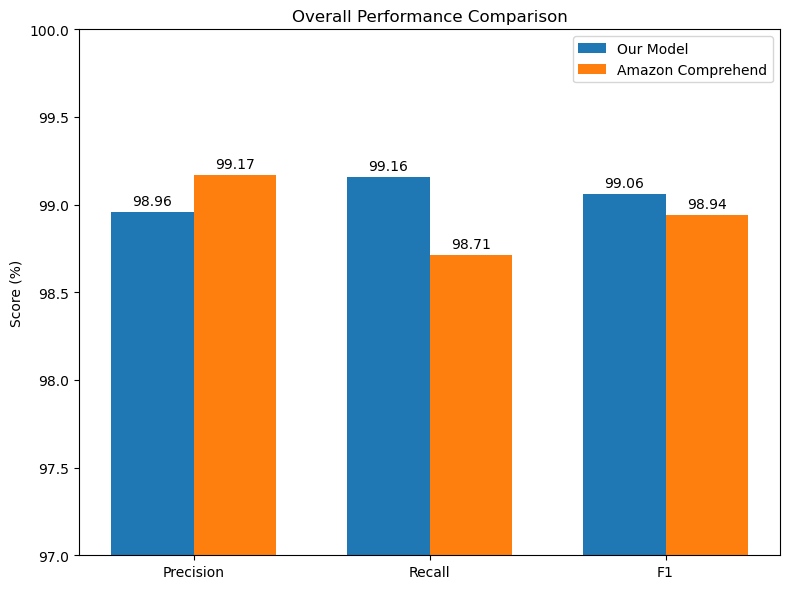

In [ ]:

# Our system scores (convert to percentages)
our_scores = [results["scores"]["precision"]*100,
              results["scores"]["recall"]*100,
              results["scores"]["F1"]*100]

# Results from Amazon Comprehend
amazon_scores = [99.17, 98.71, 98.94]

plot_overall_performance(["Precision", "Recall", "F1"], our_scores, amazon_scores, output_file="overall_performance.png")

In [ ]:
def compute_token_counts(file_path, gold_col="labeled_text"):
    """
    Reads the CSV file and computes token counts for each placeholder
    based on the gold (labeled) texts.
    
    Parameters:
      - file_path: Path to the CSV file.
      - gold_col: Name of the column that contains the gold texts.
      
    Returns:
      A dictionary mapping each placeholder to its count.
    """
    df = pd.read_csv(file_path)
    counts = {label: 0 for label in PLACEHOLDERS}
    pattern = re.compile(r'\b(' + '|'.join(PLACEHOLDERS) + r')\b', re.IGNORECASE)
    for text in df[gold_col]:
        for m in pattern.finditer(text):
            token = m.group().upper()
            if token in counts:
                counts[token] += 1
    return counts


def extract_masked_tokens(text, return_positions=False):
    """
    Extracts all masked tokens that match known placeholders.
    If return_positions is True, returns a list of tuples (token, start, end).
    Otherwise, returns just the list of token strings.
    """
    pattern = re.compile(r'\b(' + '|'.join(PLACEHOLDERS) + r')\b', re.IGNORECASE)
    if return_positions:
        return [(m.group(), m.start(), m.end()) for m in pattern.finditer(text)]
    else:
        return pattern.findall(text)

def map_gold_span_to_pred(gold, pred, g_start, g_end):
    """
    Maps a span (g_start, g_end) from the gold text to the corresponding span in the predicted text
    using SequenceMatcher to align the two strings.
    Returns a tuple (pred_start, pred_end). If mapping fails, returns (None, None).
    """
    sm = SequenceMatcher(None, gold, pred)
    opcodes = sm.get_opcodes()
    pred_start = None
    pred_end = None
    for tag, i1, i2, j1, j2 in opcodes:
        if g_start >= i1 and g_start < i2:
            pred_start = j1 + (g_start - i1) if tag in ("equal", "replace") else j1
        if g_end > i1 and g_end <= i2:
            pred_end = j1 + (g_end - i1) if tag in ("equal", "replace") else j1
        if pred_start is not None and pred_end is not None:
            break
    return pred_start, pred_end

def find_overlapping_token(pred_text, mapped_span, valid_labels):
    """
    Given the predicted text, a mapped span (p_start, p_end), and a set of valid labels,
    search among all tokens (extracted via regex) for one whose span overlaps with mapped_span.
    Returns a tuple (token, (start, end)) if found; otherwise (None, None).
    """
    p_tokens = extract_masked_tokens(pred_text, return_positions=True)
    p_start, p_end = mapped_span
    for token, start, end in p_tokens:
        # Check if there is any overlap
        if not (end < p_start or start > p_end):
            if token.lower() in valid_labels:
                return token, (start, end)
    return None, None

def analyze_row_aligned(original, gold, pred):
    """
    For each gold token, maps its span to the predicted text and then:
      - If mapping fails, counts as missing.
      - Otherwise, extracts a raw predicted token from the mapped span.
        If that token isn’t valid (i.e. not one of our placeholders), it searches the
        predicted text (within the mapped region) for a valid token.
      - If a valid predicted token is found, compares it with the gold token:
          * If they match (ignoring case), counts as correct.
          * Otherwise, counts as misplaced.
    Extra predicted tokens (those that are not mapped to any gold token) are counted as false positives.
    
    Returns:
      - metrics: dictionary with overall counts.
      - examples: dictionary with examples of error cases.
      - label_metrics: dictionary with per-label counts.
    """
    gold_tokens = extract_masked_tokens(gold, return_positions=True)
    metrics = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    examples = {"misplaced": []}
    # Initialize per-label counts.
    label_metrics = { label: {"gold": 0, "predicted": 0, "correct": 0,
                               "misplaced": 0, "missing": 0, "false_positive": 0}
                      for label in PLACEHOLDERS }
    
    valid_labels = {p.lower() for p in PLACEHOLDERS}
    
    for idx, (g_token, g_start, g_end) in enumerate(gold_tokens):
        token_upper = g_token.upper()
        label_metrics[token_upper]["gold"] += 1
        
        p_start, p_end = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if p_start is None or p_end is None or p_start < 0 or p_end > len(pred):
            metrics["missing"] += 1
            label_metrics[token_upper]["missing"] += 1
            examples["misplaced"].append({
                "gold": g_token,
                "predicted": None,
                "gold_span": (g_start, g_end),
                "pred_span": None,
                "note": "Mapping not found"
            })
            continue
        
        # Extract the raw predicted token from the mapped span.
        raw_pred = pred[p_start:p_end].strip()
        # If raw predicted token is not a valid label, try to find a valid candidate in the vicinity.
        if raw_pred.lower() not in valid_labels:
            candidate, candidate_span = find_overlapping_token(pred, (p_start, p_end), valid_labels)
            if candidate is not None:
                pred_token = candidate
                pred_span = candidate_span
            else:
                pred_token = raw_pred
                pred_span = (p_start, p_end)
        else:
            pred_token = raw_pred
            pred_span = (p_start, p_end)
        
        # If after recovery, the predicted token is still not valid, count as missing.
        if pred_token.lower() not in valid_labels:
            metrics["missing"] += 1
            label_metrics[token_upper]["missing"] += 1
            examples["misplaced"].append({
                "gold": g_token,
                "predicted": pred_token,
                "gold_span": (g_start, g_end),
                "pred_span": pred_span,
                "note": "No valid label found near mapped span"
            })
        else:
            # Valid predicted token found: count it for that label.
            pred_label = pred_token.upper()
            label_metrics[pred_label]["predicted"] += 1
            if pred_label == token_upper:
                metrics["correct"] += 1
                label_metrics[token_upper]["correct"] += 1
            else:
                metrics["misplaced"] += 1
                label_metrics[token_upper]["misplaced"] += 1
                examples["misplaced"].append({
                    "gold": g_token,
                    "predicted": pred_token,
                    "gold_span": (g_start, g_end),
                    "pred_span": pred_span,
                    "note": "Wrong label"
                })
    
    # Identify extra predicted tokens not mapped from any gold token.
    pred_tokens = extract_masked_tokens(pred, return_positions=True)
    mapped_spans = []
    for (g_token, g_start, g_end) in gold_tokens:
        p_span = map_gold_span_to_pred(gold, pred, g_start, g_end)
        if p_span[0] is not None and p_span[1] is not None:
            mapped_spans.append(p_span)
    for p_token, p_start, p_end in pred_tokens:
        # If no mapped span overlaps this predicted token, count it as an extra.
        if not any(not (p_end < m[0] or p_start > m[1]) for m in mapped_spans):
            # Only count if the token is valid.
            if p_token.lower() in valid_labels:
                metrics["false_positive"] += 1
                extra_label = p_token.upper()
                label_metrics[extra_label]["false_positive"] += 1
                examples["misplaced"].append({
                    "gold": None,
                    "predicted": p_token,
                    "gold_span": None,
                    "pred_span": (p_start, p_end),
                    "note": "Extra predicted token"
                })
    
    return metrics, examples, label_metrics

def analyze_masking(file_path, original_col=None, gold_col=None, pred_col=None):
    """
    Reads a CSV (or pickle) file containing evaluation results with columns:
      - Original Text,
      - Labeled Text (gold masked template), and
      - Masked Text (predicted masked template).
    Defaults: original_text, labeled_text, masked_text.
    Prints per-row metrics, per-label counts, and overall evaluation metrics (Precision, Recall, F1, Accuracy)
    along with per-label evaluation metrics.
    """
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_pickle(file_path)
    
    if hasattr(df, "dataset"):
        df = df.dataset

    print("Available columns in the DataFrame:", df.columns.tolist())
    
    if original_col is None:
        if "original_text" in df.columns:
            original_col = "original_text"
        else:
            raise ValueError("Could not determine original text column. Available columns: " + str(df.columns.tolist()))
    
    if gold_col is None:
        if "labeled_text" in df.columns:
            gold_col = "labeled_text"
        else:
            raise ValueError("Could not determine gold masked text column. Available columns: " + str(df.columns.tolist()))
    
    if pred_col is None:
        if "masked_text" in df.columns:
            pred_col = "masked_text"
        else:
            raise ValueError("Could not determine predicted masked text column. Available columns: " + str(df.columns.tolist()))
    
    required_columns = [original_col, gold_col, pred_col]
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"DataFrame does not contain the required columns: {required_columns}")

    all_metrics = {"correct": 0, "misplaced": 0, "missing": 0, "false_positive": 0}
    all_examples = {"misplaced": []}
    detailed_results = []
    overall_label_metrics = { label: {"gold": 0, "predicted": 0, "correct": 0,
                                      "misplaced": 0, "missing": 0, "false_positive": 0}
                              for label in PLACEHOLDERS }
    
    for idx, row in df.iterrows():
        metrics, examples, row_label_metrics = analyze_row_aligned(
            row[original_col],
            row[gold_col],
            row[pred_col]
        )
        detailed_results.append(metrics)
        for key in all_metrics:
            all_metrics[key] += metrics.get(key, 0)
        for ex in examples["misplaced"]:
            ex["row"] = idx
            ex["original"] = row[original_col]
            ex["labeled_text"] = row[gold_col]
            ex["masked_text"] = row[pred_col]
            all_examples["misplaced"].append(ex)
        for label in overall_label_metrics:
            for key in overall_label_metrics[label]:
                overall_label_metrics[label][key] += row_label_metrics[label][key]
    
    metrics_df = pd.DataFrame(detailed_results)
    print("\nPer-row masking metrics:")
    print(metrics_df)
    
    print("\nAggregate masking metrics:")
    for key, value in all_metrics.items():
        print(f"{key}: {value}")
    
    note_counts = {"No valid label found near mapped span": 0, "Extra predicted token": 0}
    for ex in all_examples["misplaced"]:
        note = ex.get("note", "")
        if note in note_counts:
            note_counts[note] += 1

    print("\nCount of tokens with note 'No valid label found near mapped span':", 
          note_counts["No valid label found near mapped span"])
    print("Count of tokens with note 'Extra predicted token':", 
          note_counts["Extra predicted token"])
    
    print("\nExamples of Misplaced Tokens:")
    if all_examples["misplaced"]:
        for ex in all_examples["misplaced"]:
            print(f"Row {ex['row']} | Original Text:  {ex['original']}")
            print(f"Row {ex['row']} | Labeled Text:   {ex['labeled_text']}")
            print(f"Row {ex['row']} | Masked Text:    {ex['masked_text']}")
            print(f"  Note: {ex.get('note', '')}")
            print(f"  Gold: '{ex['gold']}' at {ex['gold_span']} vs Predicted: '{ex['predicted']}' at {ex['pred_span']}\n")
    else:
        print("No misplaced tokens found.")
    
    print(f"\nAmount of Misplaced Tokens: {len(all_examples['misplaced'])}")
    
    TP = all_metrics["correct"]
    FN = all_metrics["missing"] + all_metrics["misplaced"]
    FP = all_metrics["false_positive"] + all_metrics["misplaced"]
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    
    print("\nOverall Evaluation Metrics:")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {F1:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    
    print("\nPer-label Counts:")
    for label, counts in overall_label_metrics.items():
        print(f"{label}: {counts}")
    
    print("\nPer-label Evaluation Metrics:")
    for label, counts in overall_label_metrics.items():
        TP_label = counts["correct"]
        FN_label = counts["missing"] + counts["misplaced"]
        FP_label = counts["false_positive"] + counts["misplaced"]
        precision_label = TP_label / (TP_label + FP_label) if (TP_label + FP_label) > 0 else 0
        recall_label = TP_label / (TP_label + FN_label) if (TP_label + FN_label) > 0 else 0
        f1_label = 2 * precision_label * recall_label / (precision_label + recall_label) if (precision_label + recall_label) > 0 else 0
        print(f"{label} - Precision: {precision_label:.3f}, Recall: {recall_label:.3f}, F1: {f1_label:.3f}")
    
    return all_metrics, metrics_df, all_examples, overall_label_metrics

if __name__ == "__main__":
    aggregate_metrics, per_row_metrics, examples, label_metrics = analyze_masking("dataset_1.csv")


Available columns in the DataFrame: ['original_text', 'labeled_text', 'masked_text']

Per-row masking metrics:
      correct  misplaced  missing  false_positive
0           2          0        0               0
1           2          0        0               0
2           2          0        0               0
3           1          0        0               0
4           3          0        0               0
...       ...        ...      ...             ...
4265        1          0        0               0
4266        2          0        0               0
4267        1          0        0               0
4268        2          0        0               0
4269        2          0        0               0

[4270 rows x 4 columns]

Aggregate masking metrics:
correct: 8728
misplaced: 42
missing: 34
false_positive: 31

Count of tokens with note 'No valid label found near mapped span': 32
Count of tokens with note 'Extra predicted token': 31

Examples of Misplaced Tokens:
Row 14 | Original Tex

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_entity_f1(overall_label_metrics, token_counts, output_file=None):
    """
    Plots a per-entity F1 score comparison between your system and Amazon Comprehend.

    Parameters:
      - overall_label_metrics: dict mapping each entity (label) to its evaluation counts.
          Each value should be a dict with keys "correct", "misplaced", "missing", and "false_positive".
      - token_counts: dict mapping each entity to its token count.
      - output_file: if provided, saves the plot to the specified filename.

    Note: Amazon Comprehend F1 scores are hardcoded.
    """
    # Hardcoded Amazon Comprehend F1 scores.
    amazon_scores_dict = {
        "CREDITCARDNUMBER": 90.00,
        "EMAIL": 99.94,
        "GENDER": 100.00,
        "IBAN": 100.00,
        "IP": 95.41,
        "JOB": 99.85,
        "LOCATION": 96.60,
        "MASKEDNUMBER": 95.77,
        "NAME": 99.86,
        "PASSWORD": 96.55,
        "URL": 100.00,
        "USERAGENT": 92.30,
        "USERNAME": 98.55
    }
    
    # Compute your system's F1 score for each entity dynamically.
    our_f1 = {}
    for label, counts in overall_label_metrics.items():
        TP = counts["correct"]
        FN = counts["missing"] + counts["misplaced"]
        FP = counts["false_positive"] + counts["misplaced"]
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        our_f1[label] = f1 * 100  # Convert to percentage

    # Get the list of entities and sort them by token count (descending).
    entities = list(overall_label_metrics.keys())
    sorted_entities = sorted(entities, key=lambda e: token_counts.get(e, 0), reverse=True)

    # Prepare scores and labels for plotting.
    amazon_scores = [amazon_scores_dict.get(e, 0) for e in sorted_entities]
    our_scores = [our_f1.get(e, 0) for e in sorted_entities]
    labels = [f"{e} ({token_counts.get(e, 0)})" for e in sorted_entities]

    # Plot the per-entity F1 comparison.
    x = np.arange(len(sorted_entities))
    width = 0.35
    fig, ax = plt.subplots(figsize=(15, 8))
    
    ax.bar(x - width/2, amazon_scores, width, label="Amazon Comprehend", color='tab:orange')
    ax.bar(x + width/2, our_scores, width, label="Our Evaluation", color='tab:blue')
    
    ax.set_xlabel("Entity Type (Token Count)")
    ax.set_ylabel("F1 Score (%)")
    ax.set_title("Per-Entity F1 Score Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()


Available columns in the DataFrame: ['original_text', 'labeled_text', 'masked_text']

Per-row masking metrics:
      correct  misplaced  missing  false_positive
0           2          0        0               0
1           2          0        0               0
2           2          0        0               0
3           1          0        0               0
4           3          0        0               0
...       ...        ...      ...             ...
4265        1          0        0               0
4266        2          0        0               0
4267        1          0        0               0
4268        2          0        0               0
4269        2          0        0               0

[4270 rows x 4 columns]

Aggregate masking metrics:
correct: 8728
misplaced: 42
missing: 34
false_positive: 31

Count of tokens with note 'No valid label found near mapped span': 32
Count of tokens with note 'Extra predicted token': 31

Examples of Misplaced Tokens:
Row 14 | Original Tex

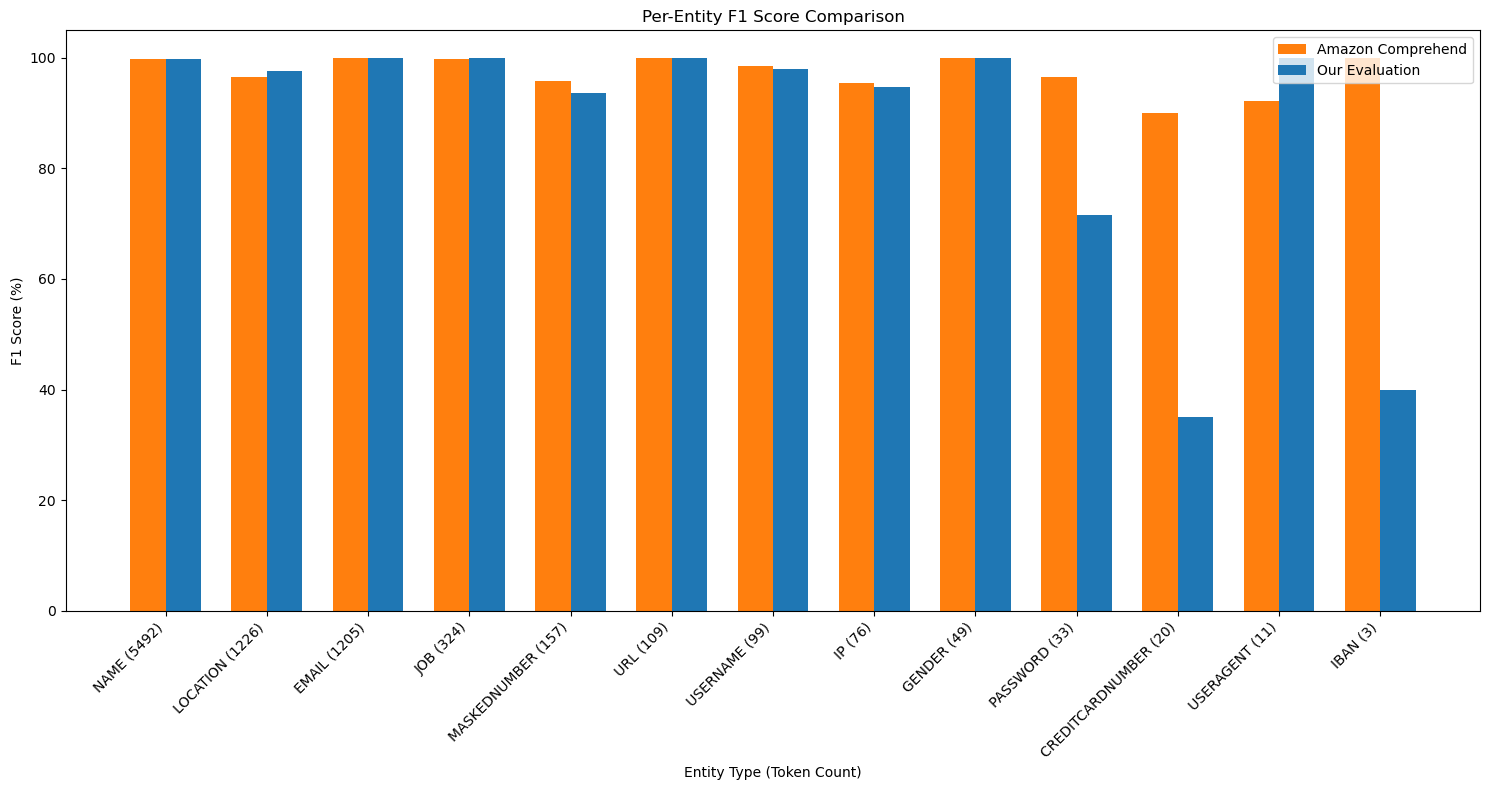

In [ ]:
# Compute token counts from the gold (labeled) texts.
token_counts = compute_token_counts("dataset_1.csv", gold_col="labeled_text")

# Analyze the masking results to get per-label evaluation metrics.
_, _, _, overall_label_metrics = analyze_masking("dataset_1.csv")

# Call the function to generate and display the per-entity F1 score diagram.
plot_entity_f1(overall_label_metrics, token_counts, output_file="entity_f1_comparison.png")


# The old results

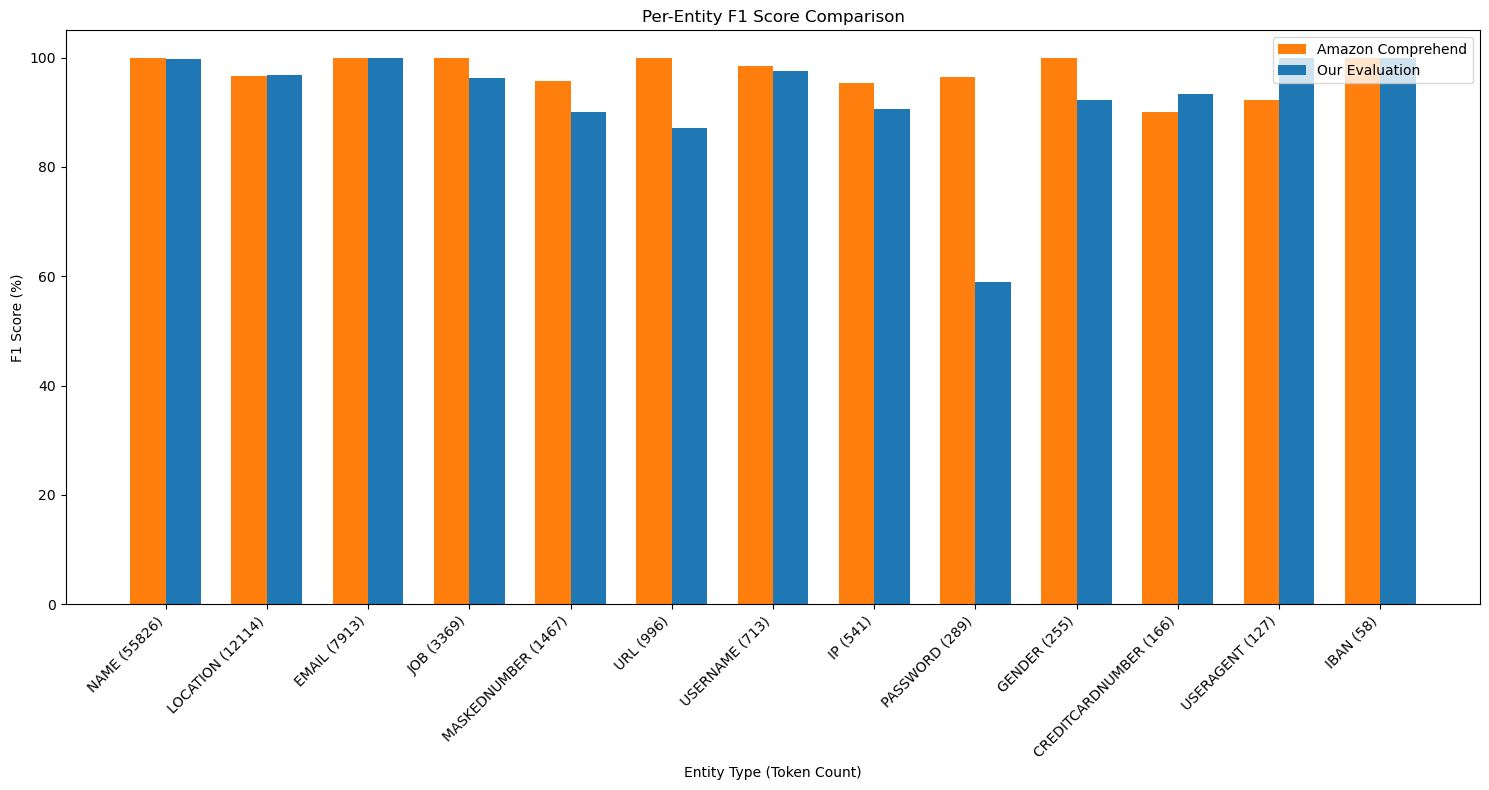

In [ ]:
def plot_entity_f1(entity_types, amazon_f1, our_f1, token_counts, output_file=None):
    """
    Plots a per-entity F1 score comparison.
    
    Parameters:
      - entity_types: list of entity names.
      - amazon_f1: list of F1 scores for the reference system.
      - our_f1: list of F1 scores for our system.
      - token_counts: dict mapping each entity to its token count.
      - output_file: if provided, saves the plot to the given filename.
    """
    # Sort entities by token count (descending)
    sorted_entities = sorted(entity_types, key=lambda e: token_counts.get(e, 0), reverse=True)
    indices = [entity_types.index(e) for e in sorted_entities]
    amazon_sorted = [amazon_f1[i] for i in indices]
    our_sorted = [our_f1[i] for i in indices]
    labels = [f"{e} ({token_counts.get(e,0)})" for e in sorted_entities]
    
    x = np.arange(len(sorted_entities))
    width = 0.35
    fig, ax = plt.subplots(figsize=(15, 8))
    
    bars_amazon = ax.bar(x - width/2, amazon_sorted, width, label="Amazon Comprehend", color='tab:orange')
    bars_our = ax.bar(x + width/2, our_sorted, width, label="Our Evaluation", color='tab:blue')
    
    ax.set_xlabel("Entity Type (Token Count)")
    ax.set_ylabel("F1 Score (%)")
    ax.set_title("Per-Entity F1 Score Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file)
    plt.show()

# Sample data for per-entity scores and token counts (adjust these with your actual data)
entity_types = ["CREDITCARDNUMBER", "EMAIL", "GENDER", "IBAN", "IP", "JOB", 
                "LOCATION", "MASKEDNUMBER", "NAME", "PASSWORD", "URL", "USERAGENT", "USERNAME"]

amazon_f1 = [90.00, 99.94, 100.00, 100.00, 95.41, 99.85, 96.60, 95.77, 99.86, 96.55, 100.00, 92.30, 98.55]
our_f1 = [93.30, 100.00, 92.30, 100.00, 90.60, 96.30, 96.80, 90.00, 99.70, 59.00, 87.20, 100.00, 97.50]
token_counts = {
    "NAME": 55826,
    "LOCATION": 12114,
    "EMAIL": 7913,
    "JOB": 3369,
    "MASKEDNUMBER": 1467,
    "URL": 996,
    "USERNAME": 713,
    "IP": 541,
    "PASSWORD": 289,
    "GENDER": 255,
    "CREDITCARDNUMBER": 166,
    "USERAGENT": 127,
    "IBAN": 58
}

plot_entity_f1(entity_types, amazon_f1, our_f1, token_counts, output_file="entity_f1_comparison.png")
